<a href="https://colab.research.google.com/github/Imaad18/TensorFlow-Keras/blob/main/TensorFlow_%26_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Setup & Imports ──────────────────────────────────────────────
# Uncomment if running in Colab or fresh environment:
# !pip install tensorflow numpy matplotlib pandas scikit-learn -q

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU') or 'None')

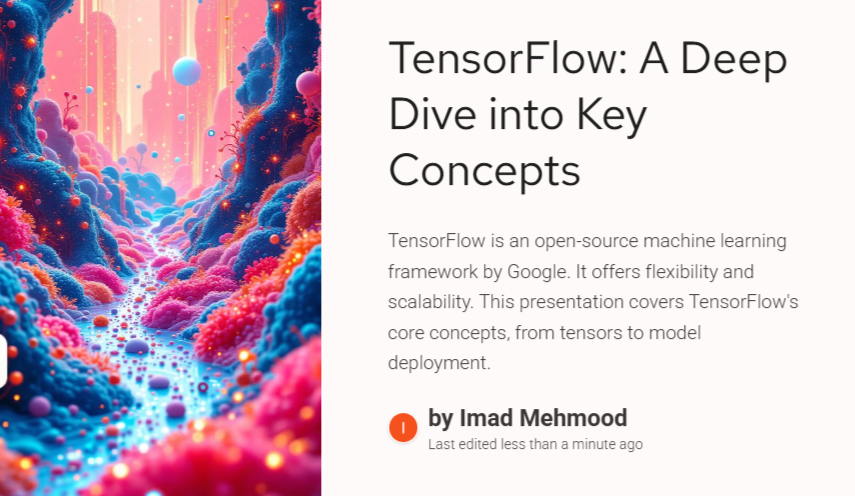

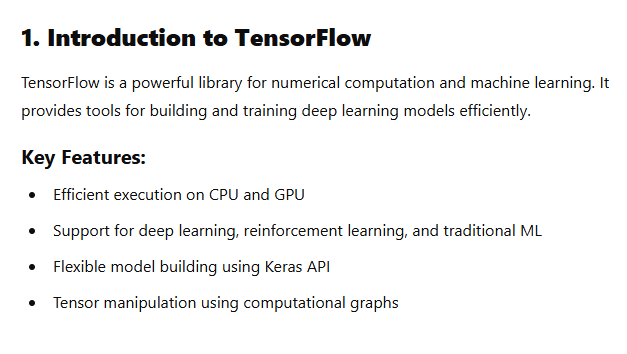

In [ ]:
# ── Tensors: Creating & Inspecting ───────────────────────────────
scalar  = tf.constant(3.14)
vector  = tf.constant([1, 2, 3, 4])
matrix  = tf.constant([[1, 2, 3], [4, 5, 6]])
tensor3 = tf.zeros((2, 3, 4))

print('Scalar :', scalar.numpy())
print('Vector :', vector.numpy())
print('Matrix shape:', matrix.shape)
print('3D Tensor shape:', tensor3.shape)
print('dtype:', matrix.dtype)

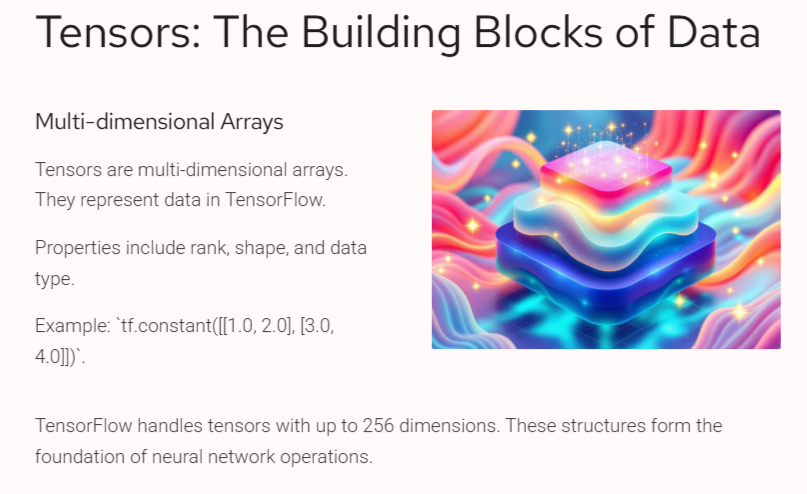

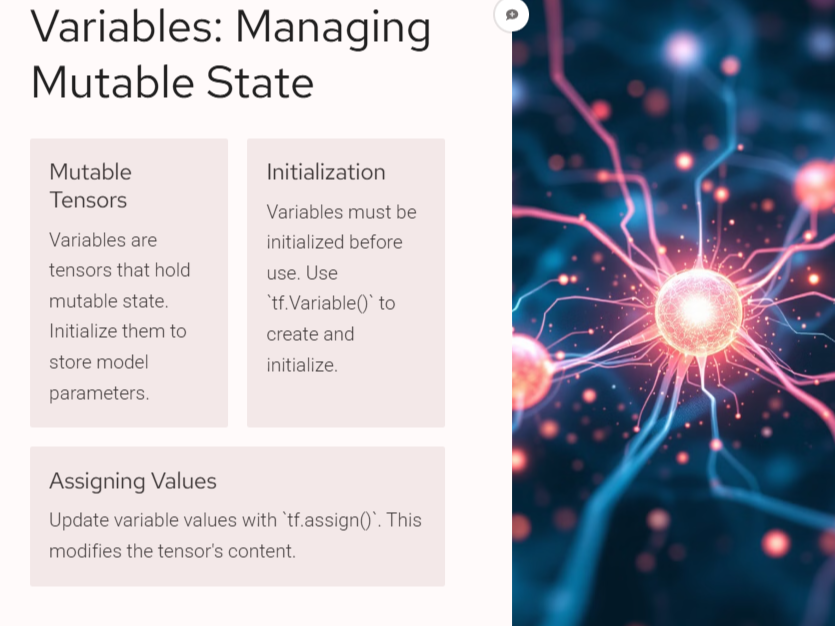

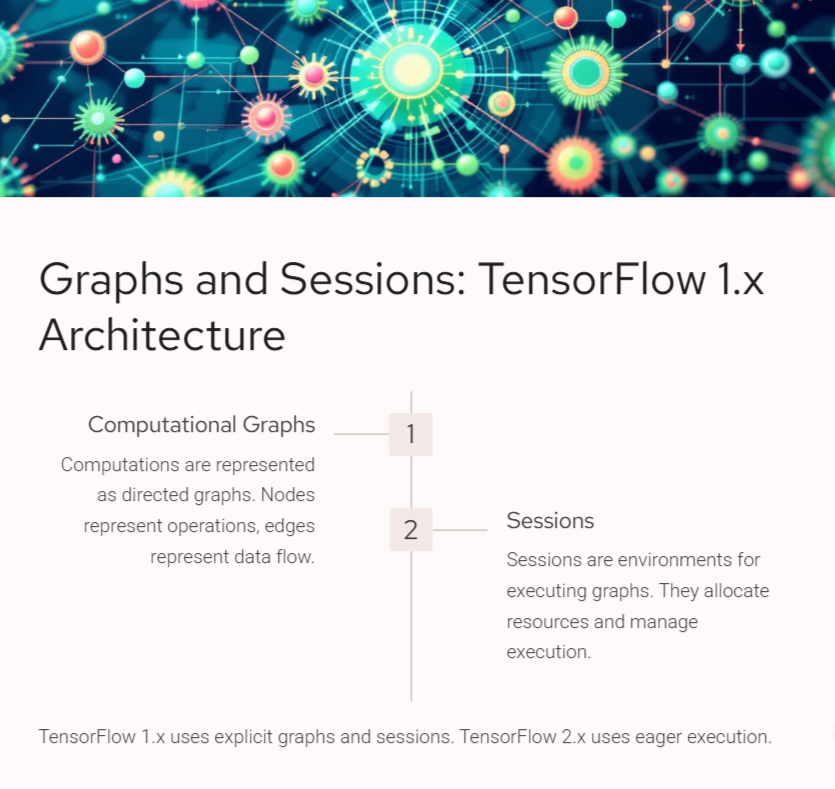

In [ ]:
# ── Tensor Operations & Variables ────────────────────────────────
a = tf.constant([1.0, 2.0, 3.0])
b = tf.constant([4.0, 5.0, 6.0])

print('Add       :', tf.add(a, b).numpy())
print('Multiply  :', tf.multiply(a, b).numpy())
print('Dot       :', tf.reduce_sum(a * b).numpy())
print('Mean      :', tf.reduce_mean(a).numpy())

# tf.Variable — mutable tensor
w = tf.Variable(tf.random.normal((3, 3)))
w.assign_add(tf.ones((3, 3)) * 0.1)
print('Variable shape:', w.shape)
print('Variable dtype:', w.dtype)

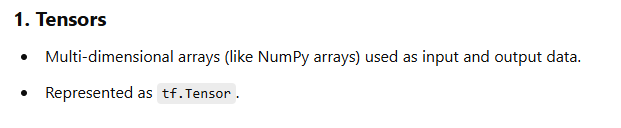

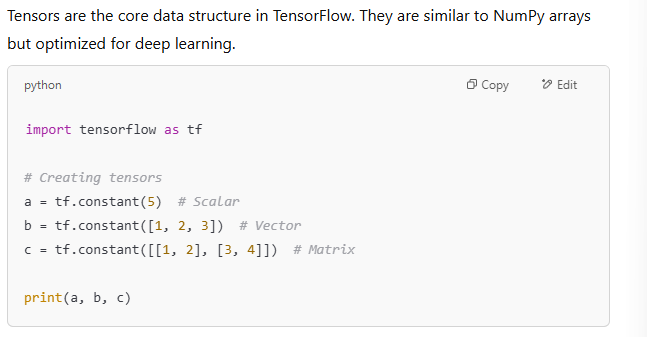

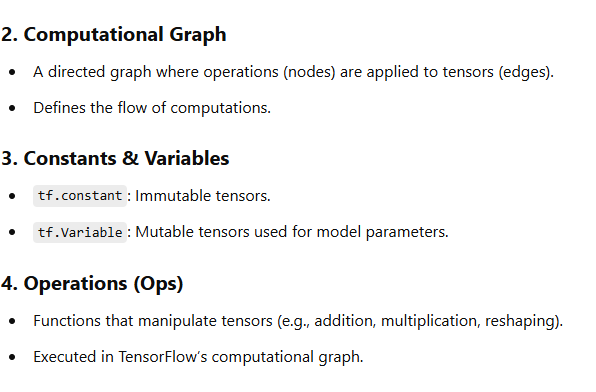

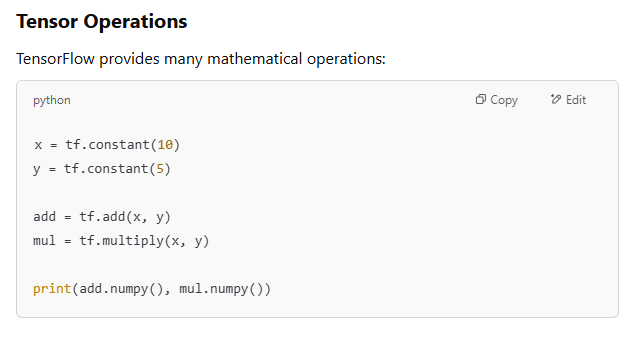

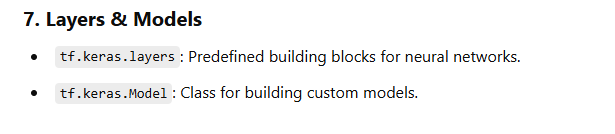

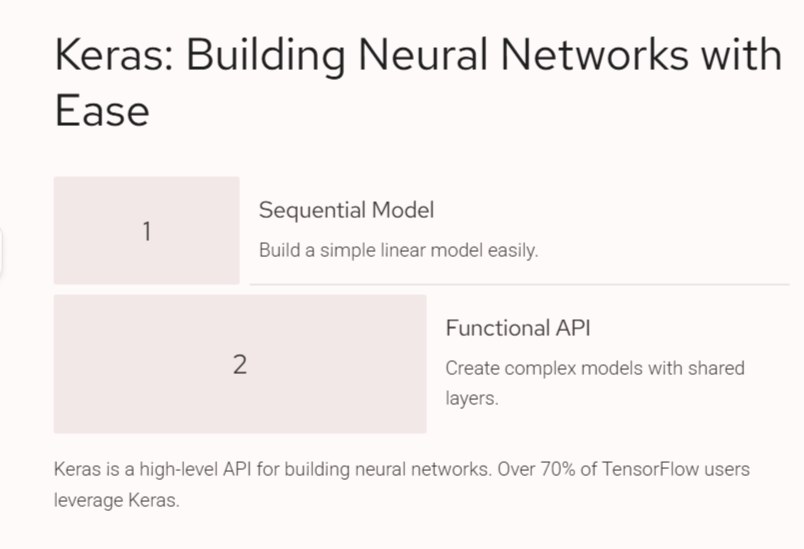

In [ ]:
# ── Neural Network Concepts ──────────────────────────────────────
# A simple Dense layer: y = activation(x @ W + b)
dense = layers.Dense(units=4, activation='relu')

x = tf.random.normal((8, 3))   # batch=8, features=3
y = dense(x)
print('Input  shape:', x.shape)
print('Output shape:', y.shape)
print('Weights shape:', dense.kernel.shape)
print('Bias    shape:', dense.bias.shape)

**Building a Neural Network with Keras**

In [ ]:
# ── Sequential API ───────────────────────────────────────────────
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(20,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax'),
], name='sequential_demo')

model.summary()

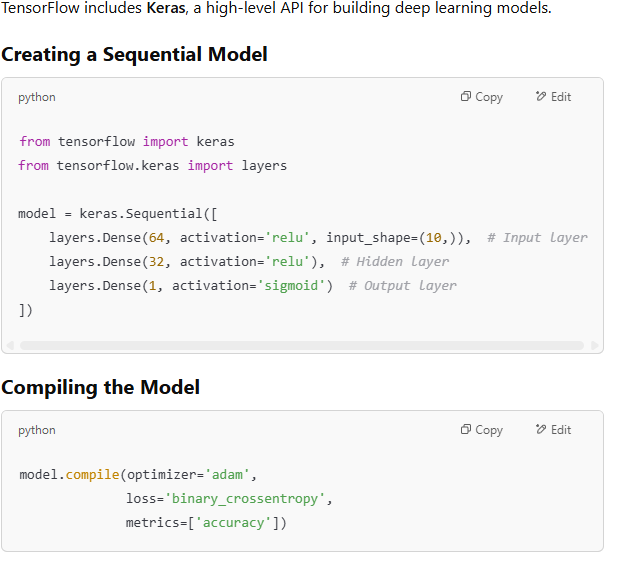

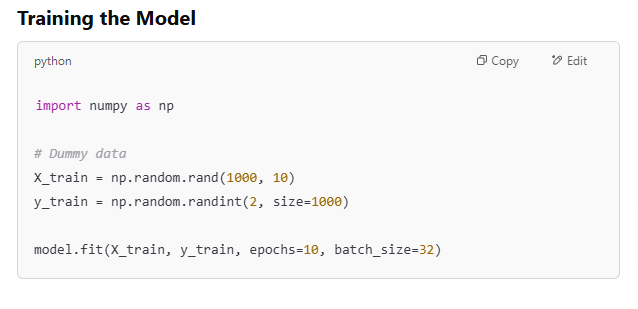

In [ ]:
# ── Compile & Train ──────────────────────────────────────────────
np.random.seed(42)
X_train = np.random.randn(800, 20).astype('float32')
y_train = np.random.randint(0, 10, 800)
X_val   = np.random.randn(200, 20).astype('float32')
y_val   = np.random.randint(0, 10, 200)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15, batch_size=32, verbose=1,
)

**Optimizers**

* Algorithms that adjust model parameters to minimize loss.

* Example: **tf.keras.optimizers.Adam(), tf.keras.optimizers.SGD().**

In [ ]:
# ── Optimizers & LR Scheduling ───────────────────────────────────
# Exponential decay schedule
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-2, decay_steps=1000, decay_rate=0.9
)

optimizers = {
    'Adam'    : keras.optimizers.Adam(1e-3),
    'SGD'     : keras.optimizers.SGD(0.01, momentum=0.9),
    'RMSprop' : keras.optimizers.RMSprop(1e-3),
    'Adagrad' : keras.optimizers.Adagrad(1e-2),
    'Adam+LRS': keras.optimizers.Adam(lr_schedule),
}

for name, opt in optimizers.items():
    print(f'{name:12s} -> {opt.__class__.__name__}')

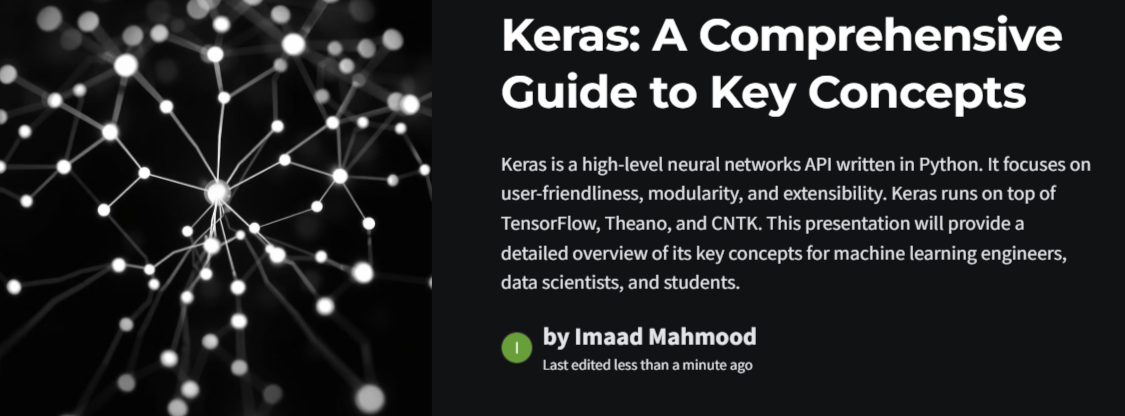

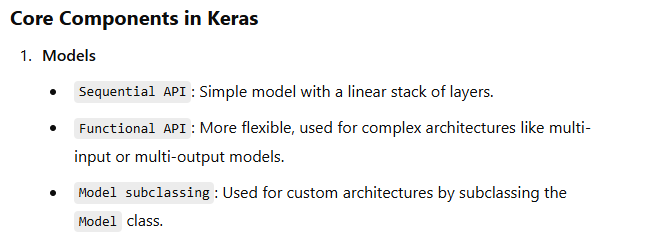

In [ ]:
# ── Plot Training History ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.set_xlabel('Epoch')

ax2.plot(history.history['accuracy'],     label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Accuracy'); ax2.legend(); ax2.set_xlabel('Epoch')

plt.tight_layout(); plt.show()

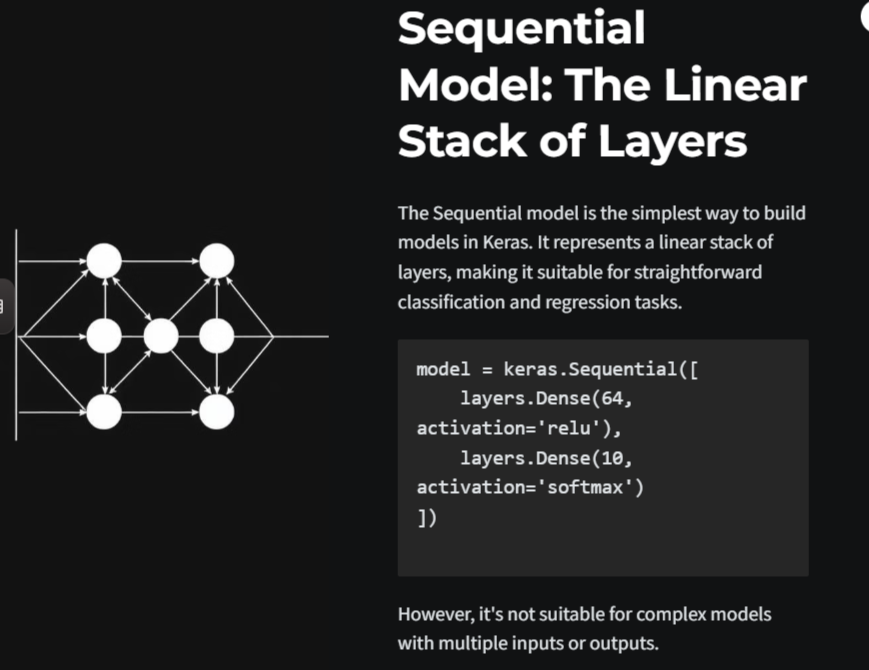

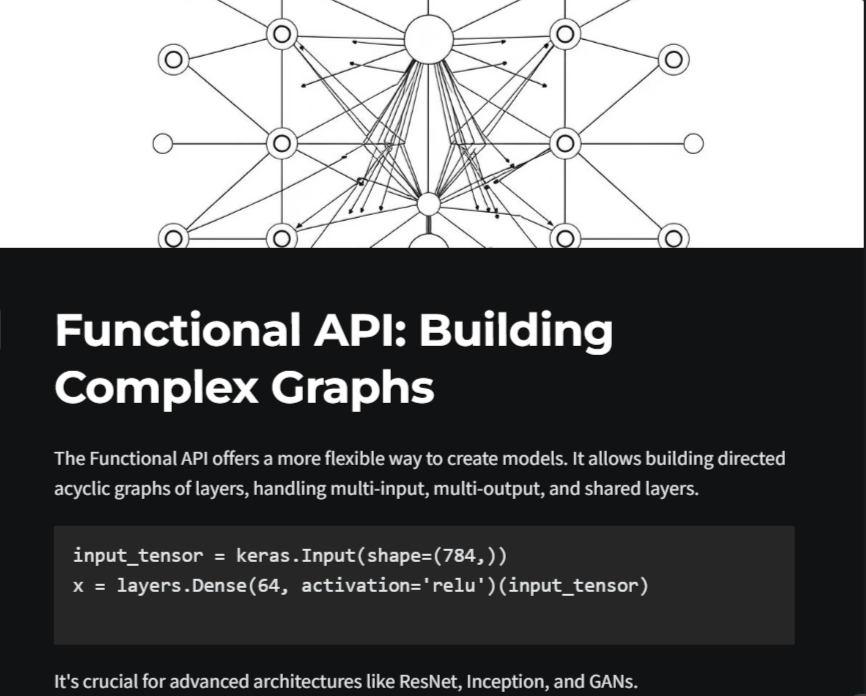

In [ ]:
# ── Evaluate & Predict ───────────────────────────────────────────
loss, acc = model.evaluate(X_val, y_val, verbose=0)
print(f'Validation Loss    : {loss:.4f}')
print(f'Validation Accuracy: {acc:.4f}')

# Predictions
preds = model.predict(X_val[:5], verbose=0)
classes = np.argmax(preds, axis=1)
print('Predicted classes (first 5):', classes)
print('True labels       (first 5):', y_val[:5])

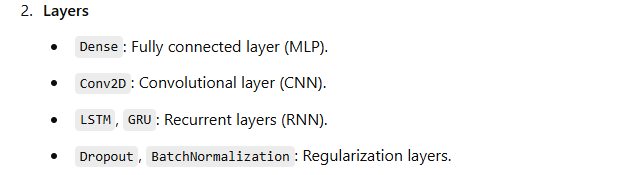

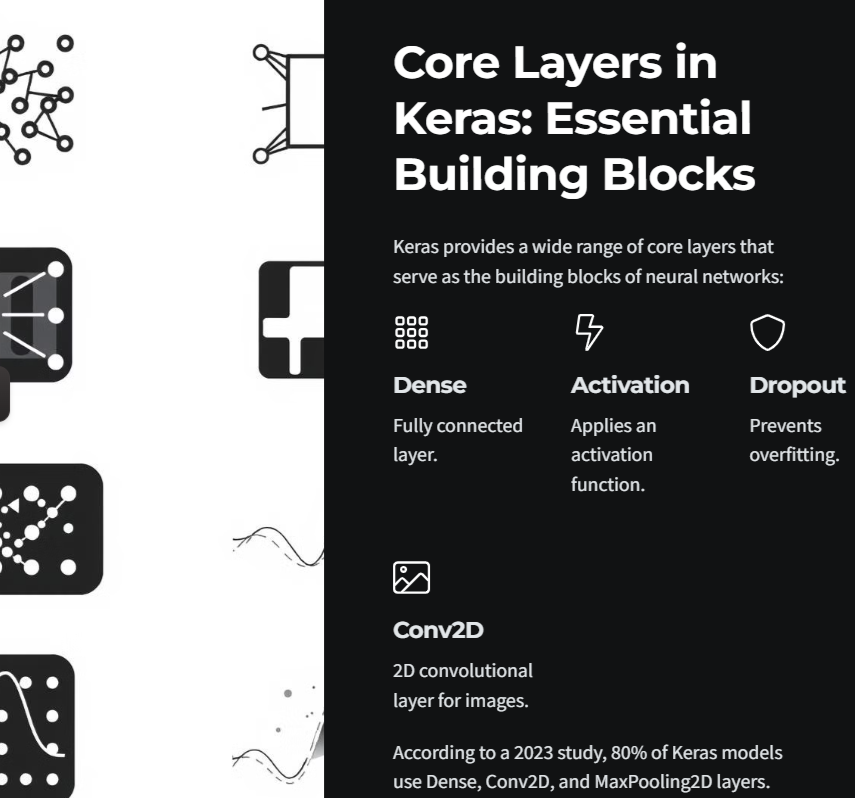

In [ ]:
# ── Overfitting: Dropout + L2 + BatchNorm + EarlyStopping ────────
reg_model = keras.Sequential([
    layers.Dense(128, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(1e-3),
                 input_shape=(20,)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(1e-3)),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax'),
])

reg_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

es = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
reg_model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=30, batch_size=32, callbacks=[es], verbose=1)

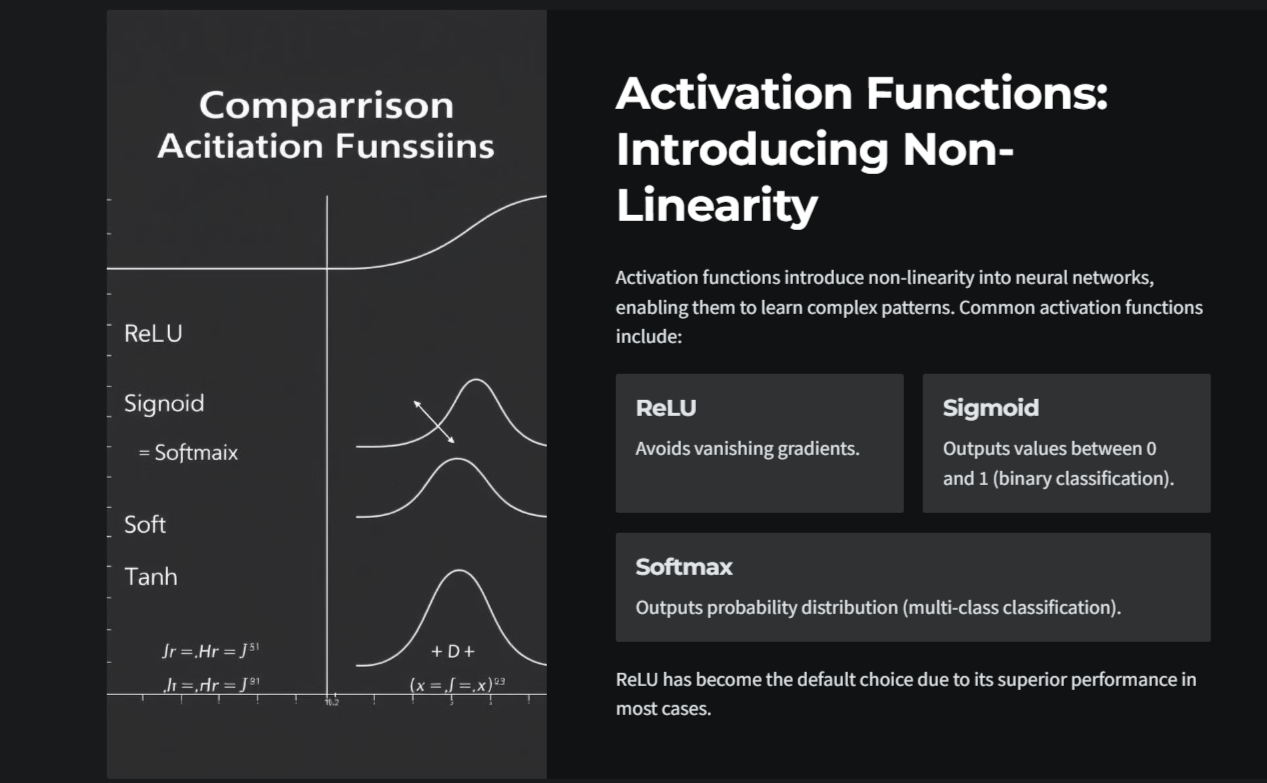

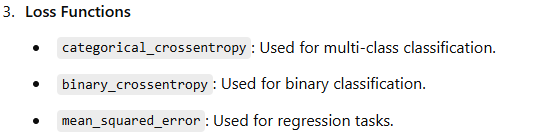

In [ ]:
# ── Save & Load Model ─────────────────────────────────────────────
# Save in native Keras format
model.save('/tmp/my_model.keras')
print('Model saved to /tmp/my_model.keras')

# Save as TensorFlow SavedModel
model.export('/tmp/my_saved_model')
print('SavedModel exported to /tmp/my_saved_model')

# Load and verify
loaded_model = keras.models.load_model('/tmp/my_model.keras')
_, orig_acc   = model.evaluate(X_val, y_val, verbose=0)
_, loaded_acc = loaded_model.evaluate(X_val, y_val, verbose=0)
print(f'Original acc : {orig_acc:.4f}')
print(f'Loaded acc   : {loaded_acc:.4f}')

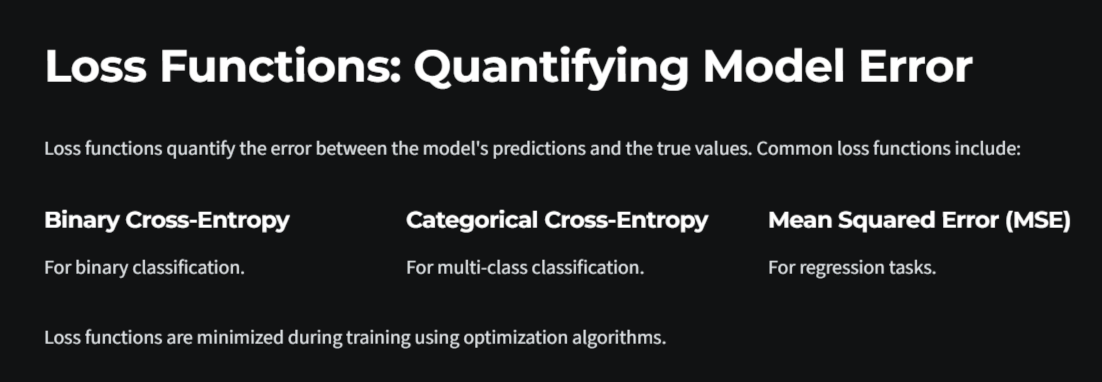

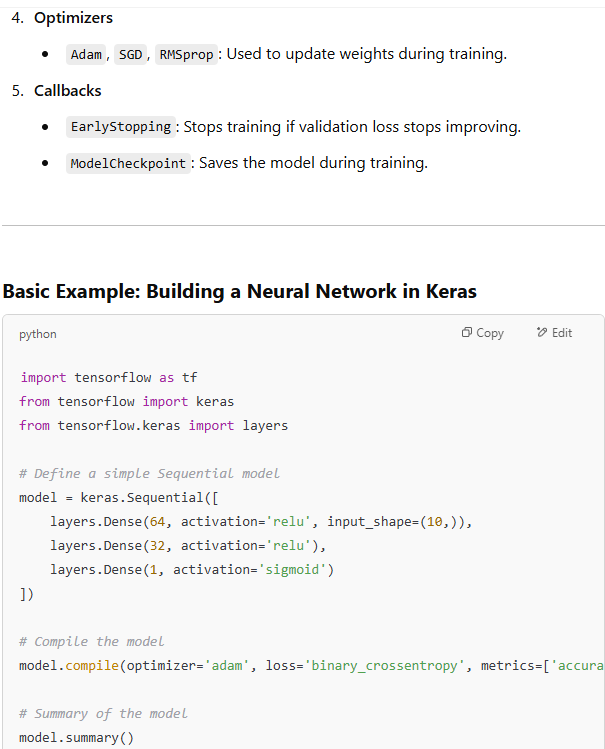

In [ ]:
# ── tf.data Pipeline ─────────────────────────────────────────────
BATCH_SIZE = 32

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(buffer_size=1000, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print('Train batches:', len(train_ds))
for xb, yb in train_ds.take(1):
    print('Batch X shape:', xb.shape, '| Batch y shape:', yb.shape)

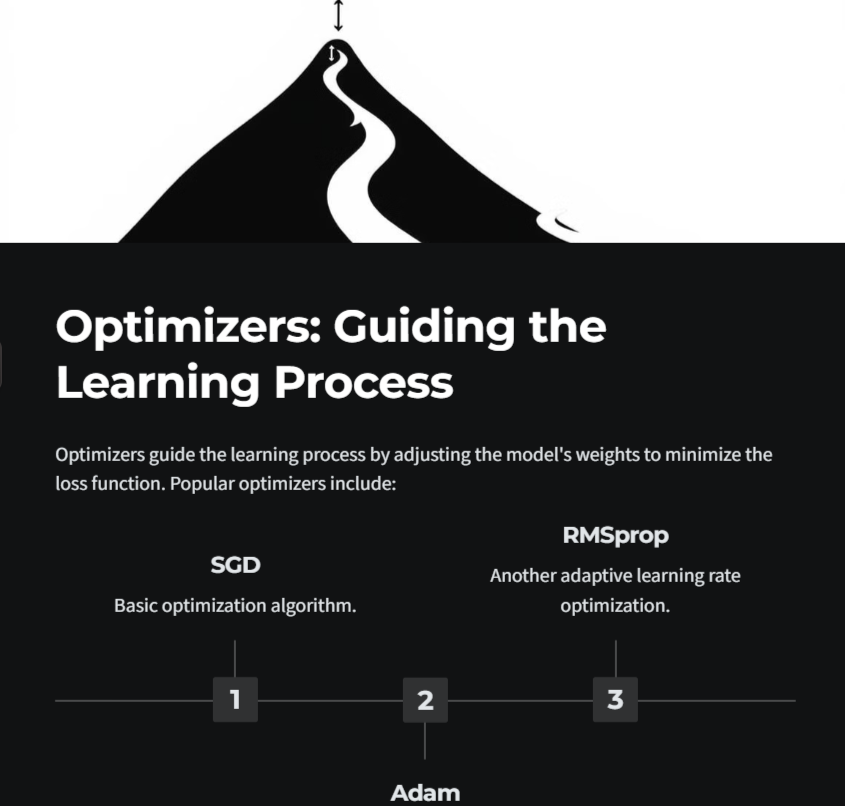

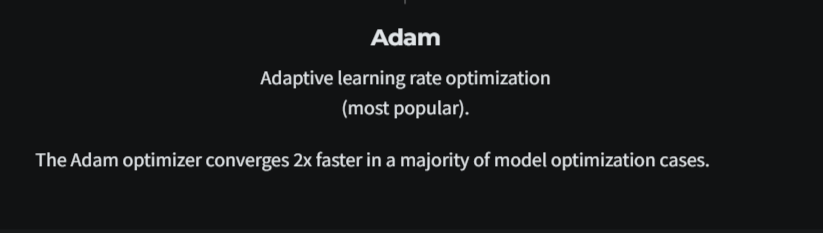

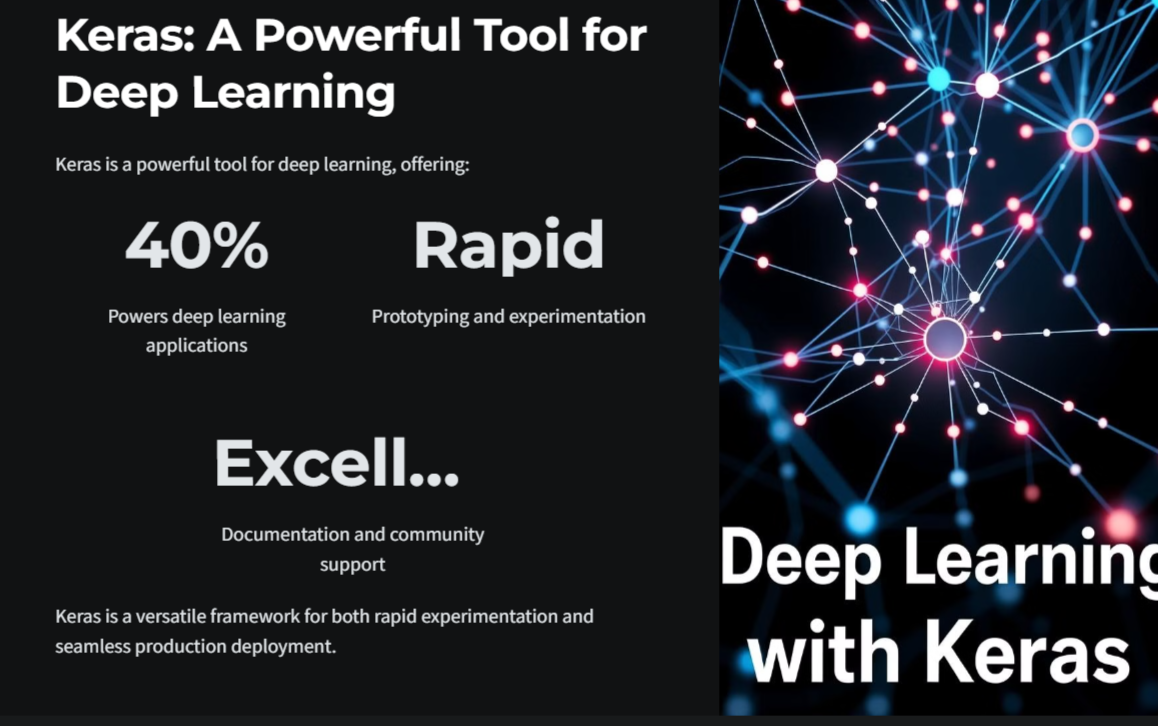

In [ ]:
# ── Functional API + Full End-to-End Example ─────────────────────
# Functional API with two outputs
inp = keras.Input(shape=(20,))
x   = layers.Dense(64, activation='relu')(inp)
x   = layers.Dropout(0.3)(x)
x   = layers.Dense(32, activation='relu')(x)
out = layers.Dense(10, activation='softmax', name='class_output')(x)

func_model = keras.Model(inputs=inp, outputs=out, name='functional_demo')
func_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
func_model.summary()

# Train using tf.data datasets
func_model.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)

# TensorBoard callback (logs written to ./logs/)
# To view: run `tensorboard --logdir logs` in terminal
tb_cb = keras.callbacks.TensorBoard(log_dir='./logs', histogram_freq=1)
print('TensorBoard callback configured. Run: tensorboard --logdir logs')